In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from sklearn import metrics

In [2]:
IMAGE_H = 256
IMAGE_W = 256
BATCH_SIZE = 32
channels = 3
epochs= 50
SEED = 123

In [3]:
import os

In [4]:
base_dir = os.path.abspath(r'E:\ORAL_CANCER\oral_datasets\augmented_balanced_set')

In [5]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [6]:
print("Training directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Training directory: E:\ORAL_CANCER\oral_datasets\augmented_balanced_set\train
Validation directory: E:\ORAL_CANCER\oral_datasets\augmented_balanced_set\val
Test directory: E:\ORAL_CANCER\oral_datasets\augmented_balanced_set\test


In [7]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    shuffle=False,  # Typically you don't shuffle test data
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE
)


Found 10000 files belonging to 2 classes.
Found 104 files belonging to 2 classes.
Found 106 files belonging to 2 classes.


In [8]:
BATCH_SIZE = 32
IMAGE_H, IMAGE_W = 256, 256
CHANNELS = 3
N_CLASSES = 2

model = models.Sequential([
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=(IMAGE_H, IMAGE_W, CHANNELS)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),
    layers.Conv2D(128,  kernel_size = (3,3), activation='relu'),
    layers.Conv2D(128,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(N_CLASSES, activation='softmax'),
])

In [9]:


# view the structure of the model
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 127, 127, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 conv2d_2 (Conv2D)           (None, 123, 123, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 61, 61, 64)       0         
 2D)                                                    

In [10]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)


In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

In [12]:
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [13]:
history=model.fit(
    train_dataset,
    epochs=epochs,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_dataset,
)

Epoch 1/50


c:\Users\gaura\anaconda3\envs\my_env\lib\site-packages\keras\backend.py:5582: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


313/313 [==============================] - 56s 151ms/step - loss: 1.2986 - accuracy: 0.4974 - val_loss: 0.6953 - val_accuracy: 0.3558
Epoch 2/50
313/313 [==============================] - 42s 133ms/step - loss: 0.6864 - accuracy: 0.5387 - val_loss: 0.6348 - val_accuracy: 0.6442
Epoch 3/50
313/313 [==============================] - 41s 131ms/step - loss: 0.6586 - accuracy: 0.6014 - val_loss: 0.7035 - val_accuracy: 0.5000
Epoch 4/50
313/313 [==============================] - 41s 131ms/step - loss: 0.6326 - accuracy: 0.6344 - val_loss: 0.5419 - val_accuracy: 0.7019
Epoch 5/50
313/313 [==============================] - 41s 131ms/step - loss: 0.5644 - accuracy: 0.7074 - val_loss: 0.5404 - val_accuracy: 0.7019
Epoch 6/50
313/313 [==============================] - 41s 131ms/step - loss: 0.5209 - accuracy: 0.7355 - val_loss: 0.5511 - val_accuracy: 0.7308
Epoch 7/50
313/313 [==============================] - 41s 132ms/step - loss: 0.4787 - accuracy: 0.7645 - val_loss: 0.5345 - val_accuracy: 0.6

In [14]:
model.evaluate(test_dataset)

4/4 [==============================] - 1s 257ms/step - loss: 1.5726 - accuracy: 0.7642


[1.57262122631073, 0.7641509175300598]

In [15]:
acc= history.history['accuracy']
val_acc = history.history['val_accuracy']

loss= history.history['loss']
val_loss = history.history['val_loss']

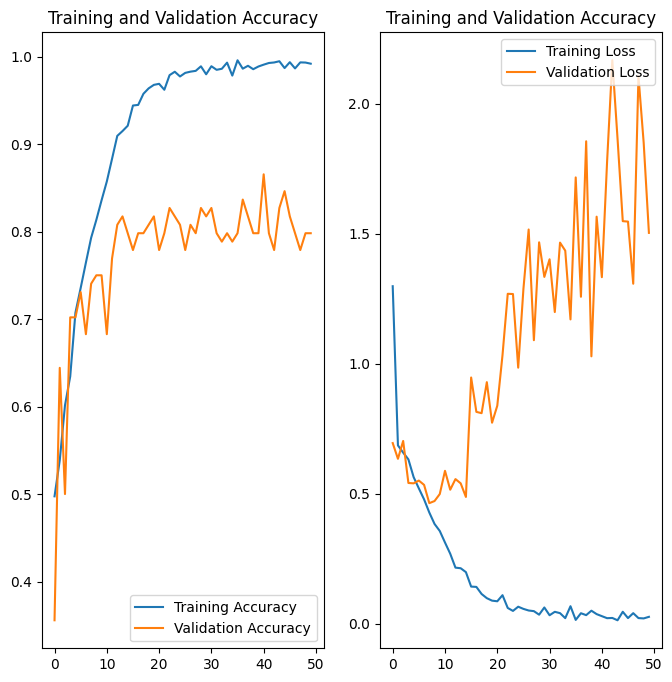

In [16]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')
plt.show()

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import numpy as np

In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Extract all test images and labels from the test dataset
test_images = []
test_labels = []

for images, labels in test_dataset:
    test_images.append(images)
    test_labels.append(labels)

test_images = tf.concat(test_images, axis=0)
test_labels = tf.concat(test_labels, axis=0)

# Predict using the trained model
y_pred = np.argmax(model.predict(test_images), axis=-1)
y_true = test_labels.numpy()

# Get class names from the dataset
class_names = test_dataset.class_names
print("Class Names:", class_names)

# Print classification report and confusion matrix
print("Classification Report:\n", classification_report(y_true, y_pred, labels=range(len(class_names)), target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


4/4 [==============================] - 1s 104ms/step
Class Names: ['400x Normal Oral Cavity Histopathological Images', '400x OSCC Histopathological Images']
Classification Report:
                                                   precision    recall  f1-score   support

400x Normal Oral Cavity Histopathological Images       0.59      0.61      0.60        31
              400x OSCC Histopathological Images       0.84      0.83      0.83        75

                                        accuracy                           0.76       106
                                       macro avg       0.72      0.72      0.72       106
                                    weighted avg       0.77      0.76      0.77       106

Confusion Matrix:
 [[19 12]
 [13 62]]


In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Convert true labels and predicted labels to numpy arrays if they aren't already
y_true = test_labels.numpy() if hasattr(test_labels, 'numpy') else test_labels
y_pred = np.asarray(y_pred)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Compute overall metrics
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Compute specificity for each class
TN = np.zeros(len(class_names))
FP = np.zeros(len(class_names))
for i in range(len(class_names)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP[i] = np.sum(cm[:, i]) - TP
    TN[i] = np.sum(cm) - (TP + FP[i] + FN)

specificity = np.mean(TN / (TN + FP))

# Display results
print(f"\nOverall Precision (macro):   {precision:.4f}")
print(f"Overall Recall (macro):      {recall:.4f}")
print(f"Overall Specificity (macro): {specificity:.4f}")
print(f"Overall F1 Score (macro):    {f1:.4f}")



Overall Precision (macro):   0.8352
Overall Recall (macro):      0.8148
Overall Specificity (macro): 0.8148
Overall F1 Score (macro):    0.8239


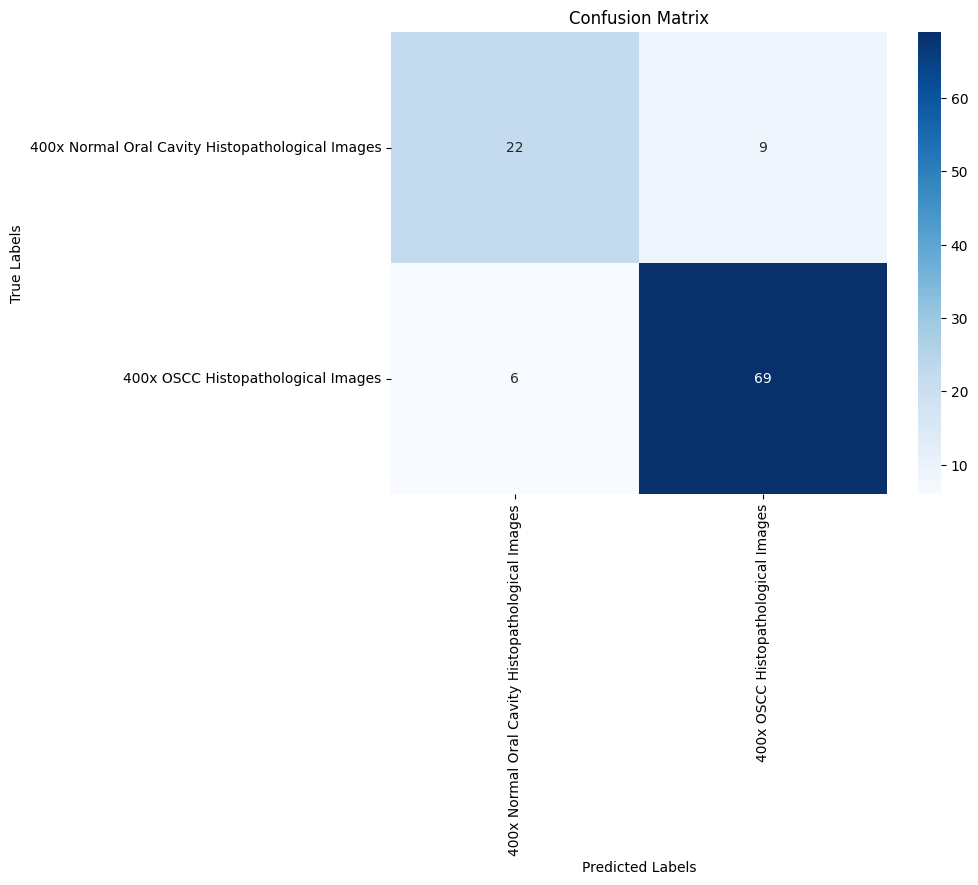

In [23]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

1/1 [==============================] - 0s 31ms/step
AUC Score: 0.8908


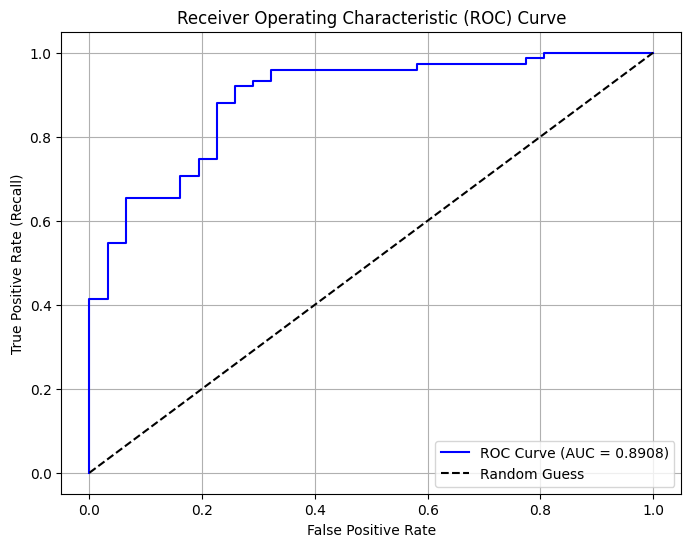

In [24]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# Collect true labels and predicted scores
y_true = []
y_scores = []

for images, labels in test_dataset:
    preds = model.predict(images)

    # If your model has a sigmoid output for binary classification:
    if preds.shape[1] == 1 or len(preds.shape) == 1:
        preds = preds.flatten()
    else:
        preds = preds[:, 1]  # Use the probability of class 1 in softmax

    y_true.extend(labels.numpy())
    y_scores.extend(preds)

y_true = np.array(y_true)
y_scores = np.array(y_scores)

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc_score = roc_auc_score(y_true, y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
